In [1]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

class DynamicDriftModel:
    def __init__(self, dt=0.001, t_max=2.0):
        """
        Initializes the model grid.
        dt: Time step size (seconds)
        t_max: Maximum duration to evaluate
        """
        self.dt = dt
        self.t_max = t_max
        self.t_grid = np.arange(dt, t_max + dt, dt) # Start at dt to avoid t=0 issues

    def get_drift_at_t(self, t, mu_c, A, alpha, tau):
        """
        Calculates the instantaneous drift rate mu(t).
        mu(t) = mu_c + A * GammaPDF(t)
        """
        # Gamma PDF from scipy (parameterized by alpha=a, scale=tau)
        gamma_drift = stats.gamma.pdf(t, a=alpha, scale=tau)
        return mu_c + (A * gamma_drift)

    def get_effective_boundary(self, mu_c, A, alpha, tau, b, sigma):
        """
        Transforms the problem into Standard Brownian Motion (drift=0, diff=1)
        crossing a time-varying boundary B(t).
        
        B(t) = (b - Integrated_Drift(t)) / sigma
        """
        # 1. Calculate Cumulative Drift M(t)
        # Integral of constant mu_c is mu_c * t
        # Integral of A * GammaPDF is A * GammaCDF
        gamma_cdf = stats.gamma.cdf(self.t_grid, a=alpha, scale=tau)
        M_t = (mu_c * self.t_grid) + (A * gamma_cdf)
        
        # 2. Calculate Effective Boundary
        # We divide by sigma to normalize the noise to 1
        B_t = (b - M_t) / sigma
        return B_t

    def solve_fpt_density(self, mu_c, A, alpha, tau, b, sigma):
        """
        Solves the Volterra Integral Equation numerically to find the PDF 
        of the first passage time.
        
        Method: Smith (2000) discretization of the integral of the first kind.
        """
        t = self.t_grid
        dt = self.dt
        boundary = self.get_effective_boundary(mu_c, A, alpha, tau, b, sigma)
        
        # PDF array to fill
        g = np.zeros_like(t)
        
        # Pre-calculate standard normal terms
        # Phi(B(t) / sqrt(t))
        Phi_upper = stats.norm.cdf(boundary / np.sqrt(t))
        
        # The integral equation states that the probability of the unconstrained process
        # being above the boundary at time t is equal to the convolution of the 
        # FPT density and the transition probability.
        # Unconstrained Prob: P(W_t >= B_t) = 1 - Phi(B_t / sqrt(t))
        lhs = 1.0 - Phi_upper

        # Numerical solution loop (Time-stepping)
        for i in range(len(t)):
            # Calculate the convolution integral sum for all previous steps j < i
            # Kernel K(t_i, t_j) = 1 - Phi((B(t_i) - B(t_j)) / sqrt(t_i - t_j))
            
            if i > 0:
                # Vectorized calculation for all j < i
                t_diff = t[i] - t[:i]
                b_diff = boundary[i] - boundary[:i]
                
                kernel = 1.0 - stats.norm.cdf(b_diff / np.sqrt(t_diff))
                
                # Discrete integral sum: sum(g[j] * kernel * dt)
                integral_term = np.sum(g[:i] * kernel) * dt
            else:
                integral_term = 0.0

            # Solve for g[i]
            # The term for j=i involves a singularity handled by limit properties.
            # In Smith's method, the weight for the current step is 0.5 * dt.
            # Equation: LHS[i] = integral_term + g[i] * 0.5 * dt
            
            g[i] = (lhs[i] - integral_term) / (0.5 * dt)
            
            # Clamp negatives (numerical noise)
            if g[i] < 0: g[i] = 0

        return g, boundary

    def get_likelihood_for_trial(self, rt, choice, params_opt1, params_opt2, t0):
        """
        Calculates likelihood for a specific trial in a 2-choice race.
        
        rt: Observed Response Time
        choice: 1 or 2 (which option won)
        params_optX: dicts containing {mu_c, A, alpha, tau, b, sigma}
        """
        decision_time = rt - t0
        if decision_time <= 0:
            return 1e-10 # Penalty for impossible RTs
            
        # Find index in grid closest to decision_time
        idx = int(np.round(decision_time / self.dt)) - 1
        if idx < 0 or idx >= len(self.t_grid):
            return 1e-10
            
        # Solve densities for both accumulators
        # (In a real fitting loop, you would cache these if params haven't changed)
        pdf1, _ = self.solve_fpt_density(**params_opt1)
        pdf2, _ = self.solve_fpt_density(**params_opt2)
        
        # Calculate CDFs (approximate via cumulative sum)
        cdf1 = np.cumsum(pdf1) * self.dt
        cdf2 = np.cumsum(pdf2) * self.dt
        
        # Race Model Likelihood:
        # L = PDF_winner(t) * (1 - CDF_loser(t))
        
        if choice == 1:
            L = pdf1[idx] * (1 - cdf2[idx])
        else:
            L = pdf2[idx] * (1 - cdf1[idx])
            
        return L


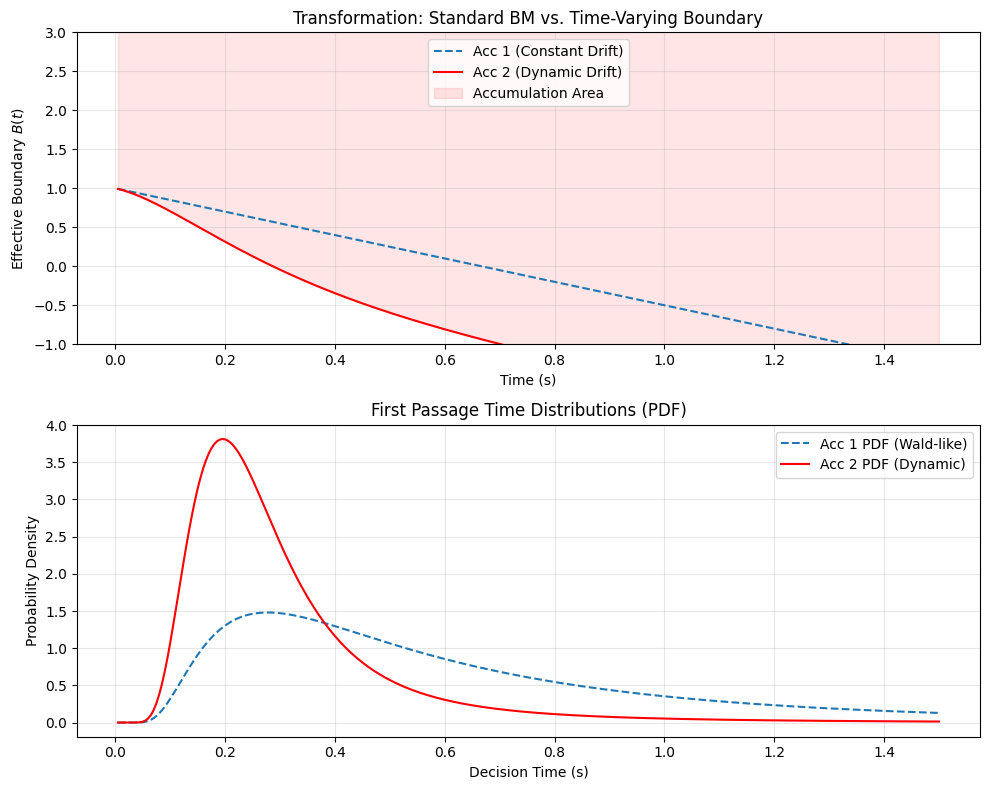

In [2]:

# --- DEMONSTRATION ---

# 1. Setup Model
model = DynamicDriftModel(dt=0.005, t_max=1.5)

# 2. Define Parameters
# Accumulator 1: Constant drift (A=0)
params_acc1 = {
    'mu_c': 1.5, 'A': 0.0, 
    'alpha': 2.0, 'tau': 0.2, 
    'b': 1.0, 'sigma': 1.0
}

# Accumulator 2: Dynamic drift (Gamma burst added to baseline)
params_acc2 = {
    'mu_c': 1.5, 'A': 1.0, # Large burst of evidence
    'alpha': 2.0, 'tau': 0.15, # Peak around 200-300ms
    'b': 1.0, 'sigma': 1.0
}

# 3. Solve and Plot
pdf1, bound1 = model.solve_fpt_density(**params_acc1)
pdf2, bound2 = model.solve_fpt_density(**params_acc2)

plt.figure(figsize=(10, 8))

# Subplot 1: The Effective Boundaries
plt.subplot(2, 1, 1)
plt.title("Transformation: Standard BM vs. Time-Varying Boundary")
plt.plot(model.t_grid, bound1, label='Acc 1 (Constant Drift)', linestyle='--')
plt.plot(model.t_grid, bound2, label='Acc 2 (Dynamic Drift)', color='red')
plt.fill_between(model.t_grid, bound2, 4, color='red', alpha=0.1, label='Accumulation Area')
plt.ylim(-1, 3)
plt.ylabel('Effective Boundary $B(t)$')
plt.xlabel('Time (s)')
plt.legend()
plt.grid(True, alpha=0.3)

# Subplot 2: The Resulting PDF (Likelihood of hitting threshold)
plt.subplot(2, 1, 2)
plt.title("First Passage Time Distributions (PDF)")
plt.plot(model.t_grid, pdf1, label='Acc 1 PDF (Wald-like)', linestyle='--')
plt.plot(model.t_grid, pdf2, label='Acc 2 PDF (Dynamic)', color='red')
plt.ylabel('Probability Density')
plt.xlabel('Decision Time (s)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [3]:
%%timeit

pdf1, bound1 = model.solve_fpt_density(**params_acc1)

15.5 ms ± 1.26 ms per loop (mean ± std. dev. of 7 runs, 100 loops each)


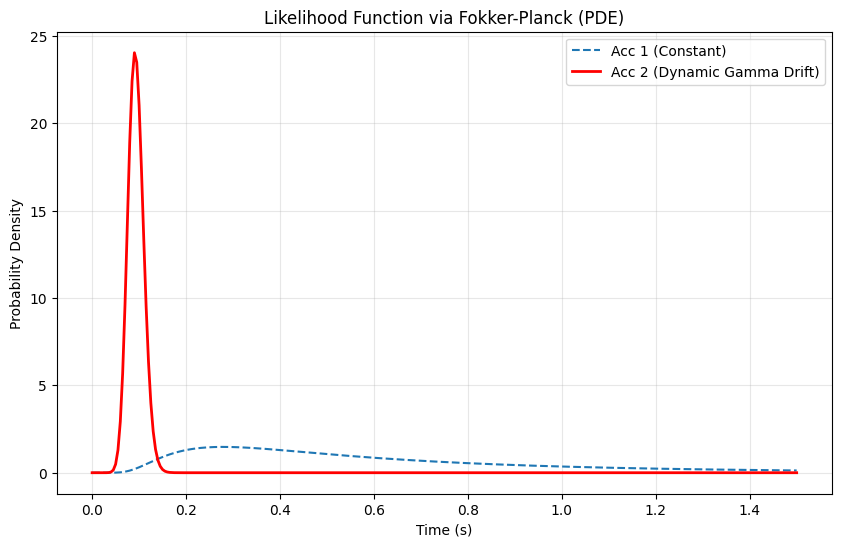

In [4]:
import numpy as np
import scipy.sparse as sparse
import scipy.sparse.linalg as splinalg
import matplotlib.pyplot as plt
import scipy.stats as stats

def solve_fokker_planck(mu_func, b, sigma, t_max=1.5, dt=0.005, dx=0.01):
    """
    Solves the Fokker-Planck equation to find the First Passage Time PDF.
    
    Args:
        mu_func: Function that takes time t and returns drift mu(t)
        b: Threshold (Absorbing boundary)
        sigma: Diffusion standard deviation
        t_max: Max time
        dt: Time step size
        dx: Space step size
    """
    # 1. Setup Grids
    # We need a lower bound far enough away that probability doesn't hit it much
    # For a Race model, accumulators can go negative, so we go deep.
    lower_bound = -b - (4 * sigma * np.sqrt(t_max)) 
    x = np.arange(lower_bound, b + dx, dx) # Grid from lower to b
    t_steps = np.arange(0, t_max + dt, dt)
    
    N = len(x)
    M = len(t_steps)
    
    # 2. Initial Condition: Delta function at 0
    p = np.zeros(N)
    # Find index closest to zero
    idx_0 = np.argmin(np.abs(x))
    p[idx_0] = 1.0 / dx # Normalize so area is 1
    
    # Storage for the First Passage Time PDF
    fpt_pdf = np.zeros(M)
    
    # Coefficients for Crank-Nicolson
    # The PDE is: dp/dt = -mu * dp/dx + (sigma^2/2) * d2p/dx2
    D = (sigma**2) / 2
    
    # Coefficients for the finite difference matrix (alpha and beta)
    # alpha handles diffusion: D * dt / (2 * dx^2)
    # beta handles drift: mu * dt / (4 * dx)
    alpha = D * dt / (2 * dx**2)
    
    # We pre-build the diffusion part of the matrices (constant)
    # Matrix A (Left Hand Side) and B (Right Hand Side)
    # (I - dt/2 * L) p_new = (I + dt/2 * L) p_old
    
    # Diagonals for Diffusion (constant)
    main_diag_diff = 1 + 2 * alpha
    off_diag_diff = -alpha
    
    main_diag_diff_rhs = 1 - 2 * alpha
    off_diag_diff_rhs = alpha

    current_mass = 1.0

    for i, t in enumerate(t_steps[:-1]):
        # Get current drift
        mu = mu_func(t)
        
        # Beta depends on drift, so it changes every step
        beta = mu * dt / (4 * dx)
        
        # Construct Tridiagonal Matrices
        # A * p_new = B * p_old
        
        # LHS Matrix A data
        # Lower diag: -alpha - beta
        # Main diag:  1 + 2*alpha
        # Upper diag: -alpha + beta
        dl_A = (-alpha - beta) * np.ones(N-1)
        d0_A = (1 + 2*alpha) * np.ones(N)
        du_A = (-alpha + beta) * np.ones(N-1)
        
        # Enforce Absorbing Boundary at the top (last index)
        # p[N-1] must be 0. We decouple the last node.
        d0_A[-1] = 1.0
        dl_A[-1] = 0.0 
        
        # Enforce Reflecting Boundary at bottom (0 flux)
        # p[0] = p[1] approx
        du_A[0] = -1.0
        d0_A[0] = 1.0

        A = sparse.diags([dl_A, d0_A, du_A], [-1, 0, 1], format='csc')
        
        # RHS Matrix B data
        dl_B = (alpha + beta) * np.ones(N-1)
        d0_B = (1 - 2*alpha) * np.ones(N)
        du_B = (alpha - beta) * np.ones(N-1)
        
        # Boundaries for RHS
        d0_B[-1] = 0.0 # Absorbing
        dl_B[-1] = 0.0
        du_B[0] = 0.0  # Reflecting logic handled in LHS mostly
        d0_B[0] = 0.0
        
        B = sparse.diags([dl_B, d0_B, du_B], [-1, 0, 1], format='csc')
        
        # Solve linear system
        rhs_vec = B.dot(p)
        p_new = splinalg.spsolve(A, rhs_vec)
        
        # 3. Calculate FPT (Flux out of the system)
        # The mass lost in this step is the probability of crossing.
        new_mass = np.sum(p_new) * dx
        mass_lost = current_mass - new_mass
        
        # Avoid negative noise
        if mass_lost < 0: mass_lost = 0
            
        fpt_pdf[i+1] = mass_lost / dt
        
        # Update
        p = p_new
        current_mass = new_mass

    return t_steps, fpt_pdf, p, x # Return final p and x for visualization

# --- DEFINE PARAMETERS ---
def drift_acc1(t):
    return 1.5 # Constant

def drift_acc2(t):
    # Dynamic Gamma Drift: Baseline + Burst
    # Using scipy gamma pdf for the burst
    burst = stats.gamma.pdf(t, a=2.0, scale=0.15)
    return 0.5 + (8.0 * burst)

# --- RUN SOLVER ---
t_grid, pdf_pde_1, final_dist_1, x_grid = solve_fokker_planck(drift_acc1, b=1.0, sigma=1.0)
t_grid, pdf_pde_2, final_dist_2, _      = solve_fokker_planck(drift_acc2, b=1.0, sigma=1.0)

# --- PLOT ---
plt.figure(figsize=(10, 6))

# Plot 1: PDF Results
plt.plot(t_grid, pdf_pde_1, label='Acc 1 (Constant)', linestyle='--')
plt.plot(t_grid, pdf_pde_2, label='Acc 2 (Dynamic Gamma Drift)', color='red', linewidth=2)
plt.title("Likelihood Function via Fokker-Planck (PDE)")
plt.xlabel("Time (s)")
plt.ylabel("Probability Density")
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

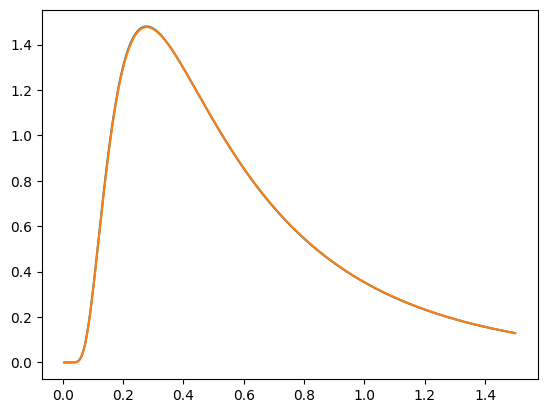

In [5]:
fig, ax = plt.subplots()

ax.plot(model.t_grid, pdf1)
ax.plot(model.t_grid, pdf_pde_1[1:])

In [6]:
%%timeit

solve_fokker_planck(drift_acc1, b=1.0, sigma=1.0)

152 ms ± 2.71 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


Compiling JAX function...
Done.


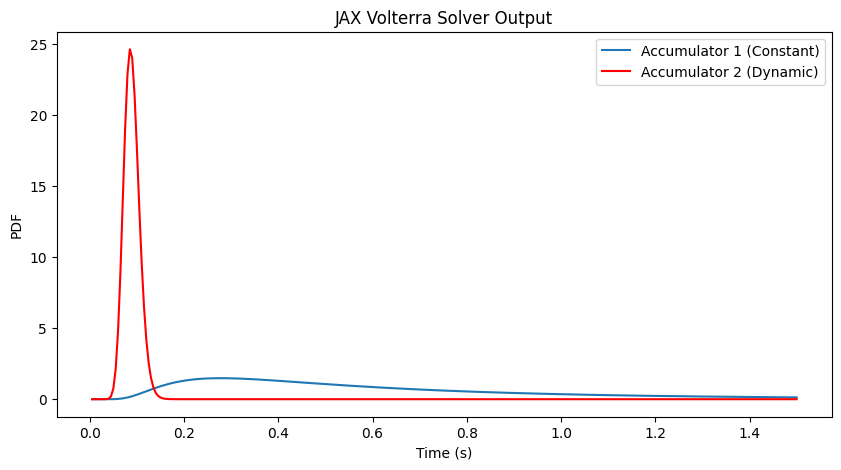

In [7]:
from functools import partial
import jax
import jax.numpy as jnp
from jax import jit, vmap, grad
from jax.scipy.stats import norm
from jax.scipy.special import gammainc, gammaln
import matplotlib.pyplot as plt

# Enable 64-bit precision (crucial for numerical stability in accumulators)
jax.config.update("jax_enable_x64", True)

@jit
def get_gamma_stats(t, alpha, tau):
    """
    Computes Gamma PDF and CDF manually for JAX stability.
    params: alpha (shape), tau (scale)
    """
    # PDF: (x^(alpha-1) * exp(-x/tau)) / (tau^alpha * Gamma(alpha))
    # Log-space calculation for stability
    log_pdf = (alpha - 1) * jnp.log(t) - (t / tau) - (alpha * jnp.log(tau)) - gammaln(alpha)
    pdf = jnp.exp(log_pdf)
    
    # CDF: Regularized lower incomplete gamma function P(a, x)
    # JAX's gammainc is P(a, x) where x is the integration limit.
    # Note: Scipy's scale notation vs mathematical notation requires checking inputs.
    # gammainc(a, x) in JAX matches the standard definition.
    cdf = gammainc(alpha, t / tau) 
    return pdf, cdf

@jit
def compute_boundary(t_grid, mu_c, A, alpha, tau, b, sigma):
    """
    Computes the effective boundary B(t) for standard Brownian motion.
    B(t) = (b - integrated_drift(t)) / sigma
    """
    _, gamma_cdf = get_gamma_stats(t_grid, alpha, tau)
    
    # Cumulative drift M(t)
    M_t = (mu_c * t_grid) + (A * gamma_cdf)
    
    # Transform boundary
    B_t = (b - M_t) / sigma
    return B_t

@jit
def volterra_step(carry, i, t_grid, boundary, dt):
    """
    One step of the Smith (2000) numerical solver.
    This function is designed to be passed to jax.lax.scan.
    """
    g_grid = carry # The history of g values
    
    t_curr = t_grid[i]
    b_curr = boundary[i]

    # --- 1. Calculate LHS Term ---
    # LHS = 1 - Phi(B(t) / sqrt(t))
    # This represents the probability the unconstrained process is above B(t)
    lhs = 1.0 - norm.cdf(b_curr / jnp.sqrt(t_curr))
    
    # --- 2. Calculate Convolution Integral (Interaction with past) ---
    # We need to compute sum(g[j] * K(t_i, t_j)) for j < i
    
    # Vectorized calculation of differences for ALL t (masked later)
    t_diff = t_curr - t_grid
    b_diff = b_curr - boundary
    
    # Handle singularity at t_diff = 0 to avoid NaNs
    # We replace 0 with 1.0 temporarily; the mask will zero it out anyway.
    safe_t_diff = jnp.where(t_diff > 0, t_diff, 1.0)
    
    # Kernel: 1 - Phi((B(t) - B(s)) / sqrt(t - s))
    kernel_vals = 1.0 - norm.cdf(b_diff / jnp.sqrt(safe_t_diff))
    
    # Create Causal Mask: only sum where index j < i
    mask = jnp.arange(len(t_grid)) < i
    
    # The integral term: sum(g * kernel * dt)
    integral_term = jnp.sum(g_grid * kernel_vals * mask) * dt
    
    # --- 3. Solve for g[i] ---
    # Smith's method weight for current step is 0.5 * dt
    g_val = (lhs - integral_term) / (0.5 * dt)
    
    # Enforce non-negativity (numerical stability)
    g_val = jnp.maximum(g_val, 0.0)
    
    # Update history grid
    g_new = g_grid.at[i].set(g_val)
    
    return g_new, g_val

@partial(jit, static_argnames=("t_max", "dt"))
def get_pdf(params, t_max=1.5, dt=0.005):
    """
    Solves the Volterra equation to return the full PDF array.
    """
    # Create grid (exclude 0 to avoid division by zero)
    t_grid = jnp.arange(dt, t_max + dt, dt)
    
    # 1. Get Boundary
    B_t = compute_boundary(t_grid, 
                           params['mu_c'], params['A'], 
                           params['alpha'], params['tau'], 
                           params['b'], params['sigma'])
    
    # 2. Run Volterra Loop via lax.scan
    # We initialize g_grid with zeros
    init_g = jnp.zeros_like(t_grid)
    indices = jnp.arange(len(t_grid))
    
    # wrapper to freeze static args for scan
    def scan_fn(carry, i):
        return volterra_step(carry, i, t_grid, B_t, dt)

    # Scan returns (final_carry, stacked_outputs)
    # The stacked_output is exactly our PDF g(t)
    _, pdf = jax.lax.scan(scan_fn, init_g, indices)
    
    return t_grid, pdf

# --- BATCHING & LIKELIHOOD ---

@partial(jit, static_argnames=("t_max", "dt"))
def race_model_likelihood(rt, choice, params_1, params_2, t0, t_max, dt):
    """
    Computes negative log likelihood for a single trial.
    Differentiable!
    """
    # 1. Adjust RT
    decision_time = rt - t0
    
    # 2. Get PDFs for both accumulators
    t_grid, pdf1 = get_pdf(params_1, t_max, dt)
    _, pdf2 = get_pdf(params_2, t_max, dt)
    
    # 3. Compute CDFs (Cumulative Sum * dt)
    cdf1 = jnp.cumsum(pdf1) * dt
    cdf2 = jnp.cumsum(pdf2) * dt
    
    # 4. Find index corresponding to decision time
    # We use soft interpolation or nearest index. For simplicity, nearest:
    idx = jnp.round(decision_time / dt).astype(int) - 1
    
    # Safety clipping for indices
    idx = jnp.clip(idx, 0, len(t_grid)-1)
    
    # 5. Calculate Likelihood
    # L = pdf_winner * (1 - cdf_loser)
    # We use jnp.where to select based on choice (avoiding python 'if')
    
    # Likelihood if choice == 1
    L1 = pdf1[idx] * (1.0 - cdf2[idx])
    
    # Likelihood if choice == 2
    L2 = pdf2[idx] * (1.0 - cdf1[idx])
    
    likelihood = jnp.where(choice == 1, L1, L2)
    
    # Avoid log(0)
    likelihood = jnp.maximum(likelihood, 1e-10)
    
    return -jnp.log(likelihood)

# Vectorize the likelihood function to handle a full dataset at once
batch_likelihood = vmap(race_model_likelihood, in_axes=(0, 0, None, None, None, None, None))

# --- DEMONSTRATION ---

# 1. Define Parameters
params_acc1 = {'mu_c': 1.5, 'A': 0.0, 'alpha': 2.0, 'tau': 0.2, 'b': 1.0, 'sigma': 1.0}
params_acc2 = {'mu_c': 0.5, 'A': 8.0, 'alpha': 2.0, 'tau': 0.15, 'b': 1.0, 'sigma': 1.0}

# 2. Run Solver (First run compiles)
print("Compiling JAX function...")
t, pdf1 = get_pdf(params_acc1)
t, pdf2 = get_pdf(params_acc2)
print("Done.")

# 3. Simulate a "Fitting" scenario
# Let's say we have a dataset of RTs and Choices
rts = jnp.array([0.3, 0.4, 0.5])
choices = jnp.array([1, 2, 1])

# Calculate total negative log likelihood
nll = jnp.sum(batch_likelihood(rts, choices, params_acc1, params_acc2, 0.1, 1.5, 0.005))

# print(f"Negative Log Likelihood: {nll}")

# 4. Plot
plt.figure(figsize=(10, 5))
plt.plot(t, pdf1, label='Accumulator 1 (Constant)')
plt.plot(t, pdf2, label='Accumulator 2 (Dynamic)', color='red')
plt.title("JAX Volterra Solver Output")
plt.xlabel("Time (s)")
plt.ylabel("PDF")
plt.legend()
plt.show()

In [8]:
%%timeit

get_pdf(params_acc1)

2.41 ms ± 60 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [9]:
from rdmc import rdmc_experiment_simple

In [10]:
data = rdmc_experiment_simple(0.05, 0.5, 20, 60, 4.5, 4, 75, 300, 2, 500, 5000, 2025)

In [11]:
rt, choice = data["x"][:, 0], data["x"][:, 1]
choice = choice + 1

In [19]:
1.5 * 1000

1500.0

In [20]:
0.005 * 1000

5.0

In [26]:
-jnp.sum(batch_likelihood(
    rt,
    choice,
    {'mu_c': 0.05, 'A': 0.0, 'alpha': 2.0, 'tau': 60, 'b': 75.0, 'sigma': 4.0},
    {'mu_c': 0.5, 'A': 20.0, 'alpha': 2.0, 'tau': 60, 'b': 75.0, 'sigma': 4.5},
    300,
    1500.0,
    10.0
))

Array(-2968.89392505, dtype=float64)

In [27]:
from mcmc import warmup, inference_loop_multiple_chains

def ll_fun(x):
    x = jnp.exp(x)
    v_intercept, v_slope, A, tau, s_true, b, t0 = x

    return -jnp.sum(batch_likelihood(
        rt,
        choice,
        {'mu_c': v_intercept, 'A': 0.0, 'alpha': 2.0, 'tau': tau, 'b': b, 'sigma': 4.0},
        {'mu_c': v_intercept + v_slope, 'A': A, 'alpha': 2.0, 'tau': tau, 'b': b, 'sigma': s_true},
        t0,
        1500.0,
        10.0
    ))

In [29]:
import blackjax

init_position = jnp.array([0.05, 0.5, 10.0, 30.0, 4.0, 70.0, 300.0])

rng_key = jax.random.key(2025)

warmup_key, sampling_key = jax.random.split(rng_key, 2)

_, last_state, warmup_parameters = warmup(blackjax.nuts, ll_fun, jnp.log(init_position), 100, warmup_key, progress_bar=True)

last_state.position.block_until_ready()
warmup_parameters

Running window adaptation


{'step_size': Array(0.00014724, dtype=float64, weak_type=True),
 'inverse_mass_matrix': Array([8.92487118e-05, 6.43777785e-05, 1.00660119e-04, 1.02897552e-04,
        1.42133382e-04, 1.07616792e-04, 6.47221770e-05], dtype=float64)}

In [30]:
jnp.exp(last_state.position)

Array([4.83186762e-02, 5.13209463e-01, 9.99068978e+00, 2.98559387e+01,
       4.38708042e+00, 6.49732945e+01, 2.96730585e+02], dtype=float64)

In [33]:
kernel = blackjax.nuts(ll_fun, **warmup_parameters).step

num_chains = 1
last_states = jax.vmap(lambda x: last_state)(jnp.arange(num_chains))

final_state = inference_loop_multiple_chains(sampling_key, kernel, last_states, 100, num_chains)
final_state.position.block_until_ready()


KeyboardInterrupt: 

In [ ]:
blackjax.diagnostics.potential_scale_reduction(final_state.position)